In [26]:
!pip install numpy pandas matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 16.1 MB/s  0:00:00
Using cached pillow-12.1.1-cp312-cp312-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [46]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import math

In [ ]:
def calculate_stability(h, k, c):
    """
    Calculate the stability of the finite difference method.

    h = step size in space

    k = step size in time

    c = diffusion constant
    """
    return c**2 * k / h**2

In [116]:
def heat_fdm(initial, left_bc, right_bc, L=1, T=1, c=1):
    """
    Finite difference solver for the heat equation.

    initial : list
        values of u(x_i,0)

    left_bc : list
        boundary values at x=0 for each time step

    right_bc : list
        boundary values at x=L for each time step
    
    L = length of rod

    T = time to solve for

    c = diffusion constant
    """

    n = len(initial) - 1
    m = len(left_bc) - 1

    h = L / n
    k = T / m

    s = c**2 * k / h**2

    # solution array
    u = np.zeros((m+1, n+1))

    # initial condition
    u[0, :] = initial

    # boundary conditions
    for j in range(m+1):
        u[j, 0] = left_bc[j]
        u[j, -1] = right_bc[j]

    # finite difference iteration
    for j in range(m):
        for i in range(1, n):
            u[j+1, i] = u[j, i] + s * (u[j, i+1] - 2*u[j, i] + u[j, i-1])
            
    x = np.linspace(0, L, n+1)
    t = np.linspace(0, T, m+1)
    grid = pd.DataFrame(u, columns=[f"x{i:.2f}" for i in x])
    grid = grid.round(1)
    grid.insert(0, "t", t)


    return grid, calculate_stability(h, k, c)

In [131]:
def heatmap(grid): 
    t = grid["t"].values
    x = np.array([float(col[1:]) for col in grid.columns if col != "t"])
    heat = grid.drop(columns="t").values

    plt.imshow(
        heat,
        aspect='auto',
        origin='lower',
        extent=[x.min(), x.max(), t.min(), t.max()],
        cmap='coolwarm'
    )

    plt.xlabel("Space (x)")
    plt.ylabel("Time (t)")
    plt.title("Heat Distribution Over Time")

    plt.colorbar(label="Temperature")
    plt.show()

Dirichlet Boundary Conditions w initial condition = [0, 30, -34, 47, 0]

Inital Condition: [0, 30, -34, 47, 0]
Solution:
          t  x0.00  x0.25  x0.50  x0.75  x1.00
0  0.000000    0.0   30.0  -34.0   47.0    0.0
1  0.166667    0.0   14.3   -9.8   25.7    0.0
2  0.333333    0.0    7.9    0.1   15.5    0.0
3  0.500000    0.0    5.3    4.0   10.3    0.0
4  0.666667    0.0    4.2    5.3    7.6    0.0
5  0.833333    0.0    3.7    5.5    5.9    0.0
6  1.000000    0.0    3.4    5.2    4.8    0.0
Stability: 0.16666666666666666
The method is stable.


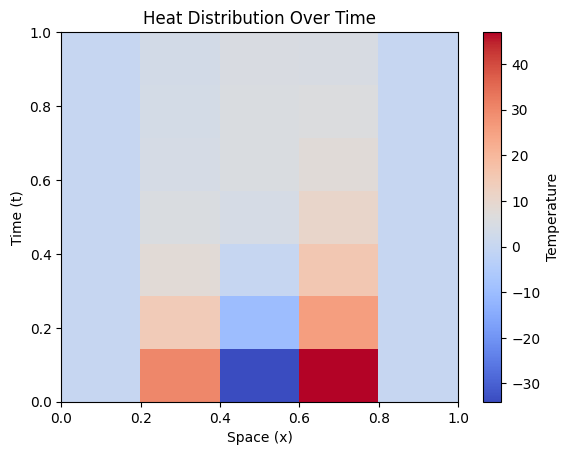

In [ ]:
initial = [0, 30, -34, 47, 0]
left_bc = [0, 0, 0, 0, 0, 0, 0]
right_bc = [0, 0, 0, 0, 0, 0, 0]

print("Inital Condition:", initial)
grid, stability = heat_fdm(initial, left_bc, right_bc, c = 1/4)

print("Solution:")
print(grid)

if stability > 0.5:
    print("Stability:", stability)
    print("The method is unstable.")
else:
    print("Stability:", stability)
    print("The method is stable.")

heatmap(grid)
